## Utilities

In [12]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
from tqdm.auto import tqdm
import statsmodels.api as sm
import warnings
import random
from IPython.display import display, HTML
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from itertools import cycle

import warnings
import humanize

from functools import partial
from statsforecast.core import StatsForecast
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    HistoricAverage,
    WindowAverage,
    SeasonalWindowAverage,
    RandomWalkWithDrift,
    HoltWinters,
    ETS,
    AutoETS,
    AutoARIMA,
    ARIMA,
    AutoTheta,
    AutoTBATS,
    MSTL
)
from datasetsforecast.losses import *
from src.utils.ts_utils import forecast_bias

import time
from src.utils import plotting_utils

# Import from new reusable modules
from thesis.data_preparation import (
    MANUAL_DATASETS, POINT_FORECAST_DATASETS,
    load_dataset,
    create_train_val_test_splits,
    initialize_results_dict,
)
from thesis.evaluation import (
    build_results_table,
    get_eval_metrics,
    evaluate_performance,
    evaluate_transformed_performance,
    format_metrics_table,
    export_latex_table,
    prepare_comparison_metrics,
    export_comparison_metrics,
    plot_forecast_matplotlib,
    style_results_table,
    color_best_per_series,
)
from thesis.model_selection import (
    export_model_selection,
    filter_metrics_to_selection,
    load_model_selection,
    model_config,
    merge_model_selections,
    selected_base_models,
    summarize_model_selection,
)
from thesis.reporting import (
    apply_matplotlib_dataset_labels,
    display_series_name,
    figure_path,
    humanize_results_table,
    publication_latex,
    save_matplotlib_figure,
)
from thesis.runtime import CPU_THREADS
from src.transforms.target_transformations import AutoStationaryTransformer

from tqdm import tqdm 
tqdm.pandas()


In [13]:
# Seed the random number generator for reproducibility
SEED = 67
CLASSICAL_N_JOBS = CPU_THREADS
np.random.seed(SEED)

# Set default plotly template
pio.templates.default = "plotly_white"

# auto reloading of imported modules (useful for dev):
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# ============================================================================
# MANUAL DATASET CONFIGURATION (imported from thesis.data_preparation)
# ============================================================================
# Synthetic panels are benchmarked only in global_models.ipynb.

# To customize: uncomment and modify below
# MANUAL_DATASETS['emae']['splits']['train'] = lambda df: df.index.year <= 2023

# ============================================================================
# EXECUTION SETTINGS
# ============================================================================

# Batch mode loops over manual datasets in one run; it does not create a global model.
EXECUTION_MODE = 'batch'  # 'single' or 'batch'
ACTIVE_DATASET = 'emae'  # used only when EXECUTION_MODE='single'
EVALUATION_SPLIT = 'test'  # use 'test' only after validation choices are frozen
CLASSICAL_MODELS_BY_DATASET = {}  # optional: {'emae': [AutoARIMA(...), ...]}
SAVE_FIGURES = True
FIGURE_FORMAT = 'jpg'

assert EXECUTION_MODE in {'single', 'batch'}
assert EVALUATION_SPLIT in {'validation', 'test'}

# Determine which datasets to process
if EXECUTION_MODE == 'single':
    datasets_to_process = [ACTIVE_DATASET]
else:
    datasets_to_process = list(POINT_FORECAST_DATASETS)
CLASSICAL_SELECTION_PATH = Path('thesis/model_configs/classical_validation_selection.json')

print(f"Execution Mode: {EXECUTION_MODE}")
print(f"Datasets to Process: {datasets_to_process}")
if EXECUTION_MODE != 'single':
    print('ACTIVE_DATASET is ignored outside single mode.')

# ============================================================================
# INITIALIZE RESULTS DICTIONARY
# ============================================================================

all_results = {}
classical_configs_by_dataset = {}
EVAL_METRICS = get_eval_metrics()

print(f"\nEvaluation Metrics: {[m.__name__ for m in EVAL_METRICS]}")

Execution Mode: batch
Datasets to Process: ['emae', 'ecai_us', 'real_gdp_argentina', 'real_gdp_us']
ACTIVE_DATASET is ignored outside single mode.

Evaluation Metrics: ['mae', 'mse', 'rmse']


In [15]:
# Reuse thesis.evaluation.plot_forecast so every modeling notebook has the
# same target-column and display-name interface.

## Forecast evaluation

Use `EVALUATION_SPLIT='validation'` while selecting models, transformations, and hyperparameters. After those choices are frozen, switch to `'test'`: models are then refit on train+validation and evaluated once on test. The AutoStationary transformer follows the same boundary and is fit only on the current fitting data.

Each reported metric summarizes the complete selected horizon for one series/model: MAE and MSE average the period errors, RMSE is the square root of the full-horizon MSE, and forecast bias compares horizon totals. Hyperparameter selection should use expanding-window rolling-origin validation; the held-out test remains untouched until the configuration is frozen.

AutoARIMA uses wider autoregressive and moving-average bounds (`p`, `q`, `P`, and `Q`), a higher total-order ceiling, and a larger stepwise search budget. Differencing remains capped at `d <= 2` and `D <= 1`: increasing those limits indiscriminately encourages over-differencing rather than a useful expansion of the candidate space.
All tables always describe the split named by `EVALUATION_SPLIT`. Therefore, they correctly show validation errors during the selection run; the test set is not evaluated automatically in the same execution. After changing the setting to `'test'` and rerunning from the top, the notebook loads the saved per-series validation selections, refits only the required winning models on train+validation, and reports those locked forecasts on test. No test-set candidate grid is produced and test errors never select a new winner.

Dataset-level forecastability diagnostics are maintained separately in [`forecastability_analysis.ipynb`](forecastability_analysis.ipynb); they are not recomputed during model evaluation.

In [16]:
# ============================================================================
# STEP 1: LOAD DATASETS AND CREATE TRAIN/VAL/TEST SPLITS
# ============================================================================

print(f"\n{'='*80}")
print("STEP 1: LOADING DATASETS")
print(f"{'='*80}\n")

all_fitted_models = {}  # Store fitted models and their parameters
frozen_selection = None
if EVALUATION_SPLIT == 'test':
    selection_file = CLASSICAL_SELECTION_PATH
    if not selection_file.exists():
        raise FileNotFoundError(
            f'No frozen validation selection found at {selection_file}; run validation first.'
        )
    frozen_selection = load_model_selection(selection_file)

for dataset_name in datasets_to_process:
    dataset_type = 'manual'
    
    print(f"Loading: {dataset_name} ({dataset_type})")
    
    # Load dataset
    df, dataset_config = load_dataset(dataset_name, dataset_type)
    
    # Create splits
    ts_train, ts_val, ts_test, id_col, time_col, target_col = create_train_val_test_splits(
        df, dataset_config, dataset_type
    )

    if EVALUATION_SPLIT == 'validation':
        fit_df, eval_df = ts_train, ts_val
    else:
        fit_df = pd.concat([ts_train, ts_val], ignore_index=True)
        eval_df = ts_test

    horizon_sizes = eval_df.groupby(id_col).size()
    if horizon_sizes.nunique() != 1:
        raise ValueError('Every series must have the same evaluation horizon')
    forecast_horizon = int(horizon_sizes.iloc[0])
    
    # Prepare data for forecasting
    pred_df = pd.concat([fit_df, eval_df])
    os.environ['NIXTLA_ID_AS_COL'] = '1'
    freq = dataset_config['freq']
    
    print(f"✓ Data loaded")
    print(f"  Train: {len(ts_train)} samples across {ts_train[id_col].nunique()} series")
    print(f"  Val: {len(ts_val)} samples across {ts_val[id_col].nunique()} series")
    print(f"  Test: {len(ts_test)} samples across {ts_test[id_col].nunique()} series")
    print(f"  Column mapping: id='{id_col}', time='{time_col}', target='{target_col}'\n")
    
    # ========================================================================
    # EVALUATE MODELS
    # ========================================================================
    
    print(f"Starting model evaluation...")
    seasonality = int(dataset_config.get('seasonality', 1))
    stationary_transformer_factory = partial(
        AutoStationaryTransformer,
        **({'seasonal_period': seasonality} if seasonality > 1 else {}),
    )
    default_models = [
        Naive(),
        SeasonalNaive(season_length=seasonality),
        WindowAverage(window_size=seasonality),
        AutoETS(
            model='AAA' if seasonality > 1 else 'AAN',
            season_length=seasonality,
        ),
        AutoARIMA(
            max_p=8, max_q=8, max_P=3, max_Q=3, max_order=15,
            max_d=2, max_D=1, seasonal=seasonality > 1,
            stepwise=True, nmodels=200,
            season_length=seasonality
        ),
        AutoTheta(season_length=seasonality),
        AutoTBATS(season_length=seasonality),
    ]
    if seasonality > 1:
        default_models.append(MSTL(season_length=seasonality))
    models = CLASSICAL_MODELS_BY_DATASET.get(dataset_name, default_models)
    original_models = models
    transformed_models = models
    if EVALUATION_SPLIT == 'test':
        original_required = set(
            selected_base_models(frozen_selection, dataset_name, 'Original')
        )
        transformed_required = set(
            selected_base_models(frozen_selection, dataset_name, 'AutoStationary')
        )
        original_models = [
            model for model in models
            if model.__class__.__name__ in original_required
        ]
        transformed_models = [
            model for model in models
            if model.__class__.__name__ in transformed_required
        ]
        available_models = {model.__class__.__name__ for model in models}
        missing_models = (original_required | transformed_required) - available_models
        if missing_models:
            raise ValueError(
                f'{dataset_name}: validation-selected classical models are unavailable: '
                f'{sorted(missing_models)}'
            )
        models = [
            model for model in models
            if model.__class__.__name__ in (original_required | transformed_required)
        ]
        for model in models:
            current_parameters = model_config(model)['parameters']
            saved_configs = [
                winner['config']
                for target_winners in frozen_selection['per_series'][dataset_name].values()
                for winner in target_winners.values()
                if winner['base_model'] == model.__class__.__name__
            ]
            saved_parameters = [record['parameters'] for record in saved_configs]
            if any(parameters != current_parameters for parameters in saved_parameters):
                raise ValueError(
                    f'{dataset_name}: {model.__class__.__name__} no longer matches its '
                    'validation configuration; restore it or re-run validation'
                )
    classical_configs_by_dataset[dataset_name] = {}
    for model in models:
        config_record = model_config(model)
        config_record['forecasting'] = {
            'freq': freq,
            'seasonality': seasonality,
            'forecast_horizon': forecast_horizon,
        }
        classical_configs_by_dataset[dataset_name][
            model.__class__.__name__
        ] = config_record
    
    original_results, original_metrics, fitted_sf_original = evaluate_performance(
        ts_train=fit_df,
        ts_test=eval_df,
        models=original_models,
        metrics=EVAL_METRICS,
        freq=freq,
        id_col=id_col,
        time_col=time_col,
        target_col=target_col,
        h=forecast_horizon,
        return_fitted_models=True,
        n_jobs=CLASSICAL_N_JOBS,
    )
    original_metrics['Base Model'] = original_metrics['Model']
    original_metrics['Target Transformation'] = 'Original'

    transformed_results, transformed_metrics, fitted_sf_transformed, forecast_transformers = (
        evaluate_transformed_performance(
            ts_train=fit_df,
            ts_test=eval_df,
            models=transformed_models,
            metrics=EVAL_METRICS,
            transformer_factory=stationary_transformer_factory,
            freq=freq,
            id_col=id_col,
            time_col=time_col,
            target_col=target_col,
            h=forecast_horizon,
            n_jobs=CLASSICAL_N_JOBS,
        )
    )
    results = original_results.merge(
        transformed_results.drop(columns=[target_col]),
        on=[id_col, time_col],
        how='left',
    )
    metrics = pd.concat([original_metrics, transformed_metrics], ignore_index=True)
    if EVALUATION_SPLIT == 'test':
        metrics = filter_metrics_to_selection(
            metrics, frozen_selection, dataset_name, series_col=id_col,
            aggregate_replicates=False,
        )
        original_metrics = metrics[
            metrics['Target Transformation'].eq('Original')
        ].copy()
        transformed_metrics = metrics[
            metrics['Target Transformation'].eq('AutoStationary')
        ].copy()
    
    print(f"✓ Evaluation complete")
    print(f"  Metrics shape: {metrics.shape}")
    print(f"  Models: {sorted(metrics['Model'].unique())}\n")
    
    # ========================================================================
    # STORE RESULTS
    # ========================================================================
    
    all_results[dataset_name] = initialize_results_dict(
        dataset_name,
        dataset_config,
        dataset_type,
        ts_train,
        ts_val,
        ts_test,
        pred_df,
        id_col,
        time_col,
        target_col,
        freq
    )
    
    # Store evaluation results
    all_results[dataset_name]['metrics'] = metrics
    all_results[dataset_name]['metrics_original'] = original_metrics
    all_results[dataset_name]['metrics_transformed'] = transformed_metrics
    all_results[dataset_name]['results'] = results
    all_results[dataset_name]['evaluation_split'] = EVALUATION_SPLIT
    all_results[dataset_name]['fit_df'] = fit_df
    all_results[dataset_name]['eval_df'] = eval_df
    
    # Store fitted models
    all_fitted_models[dataset_name] = {
        'sf_original': fitted_sf_original,
        'sf_transformed': fitted_sf_transformed,
        'forecast_transformers': forecast_transformers,
        'models': models,
        'fit_df': fit_df,
        'id_col': id_col,
        'time_col': time_col,
        'target_col': target_col
    }

print(f"\n{'='*80}")
print(f"✓ Processing complete for {len(all_results)} dataset(s)")
print(f"{'='*80}\n")


STEP 1: LOADING DATASETS

Loading: emae (manual)
✓ Data loaded
  Train: 240 samples across 1 series
  Val: 12 samples across 1 series
  Test: 12 samples across 1 series
  Column mapping: id='unique_id', time='ds', target='y'

Starting model evaluation...
Evaluating 1 models...
  Horizon: 12 steps
  Metrics: ['mae', 'mse', 'rmse']
✓ Evaluation complete
  Forecasts: 12 rows
  Metrics: 1 rows
Evaluating 1 models...
  Horizon: 12 steps
  Metrics: ['mae', 'mse', 'rmse']
✓ Evaluation complete
  Forecasts: 12 rows
  Metrics: 1 rows
✓ Evaluation complete
  Metrics shape: (2, 11)
  Models: ['AutoARIMA', 'MSTL_AutoStationary']

Loading: ecai_us (manual)
✓ Data loaded
  Train: 540 samples across 1 series
  Val: 12 samples across 1 series
  Test: 12 samples across 1 series
  Column mapping: id='unique_id', time='ds', target='y'

Starting model evaluation...
Evaluating 1 models...
  Horizon: 12 steps
  Metrics: ['mae', 'mse', 'rmse']
✓ Evaluation complete
  Forecasts: 12 rows
  Metrics: 1 rows
Eva

# Results and Visualizations



PLOTTING: emae (manual)



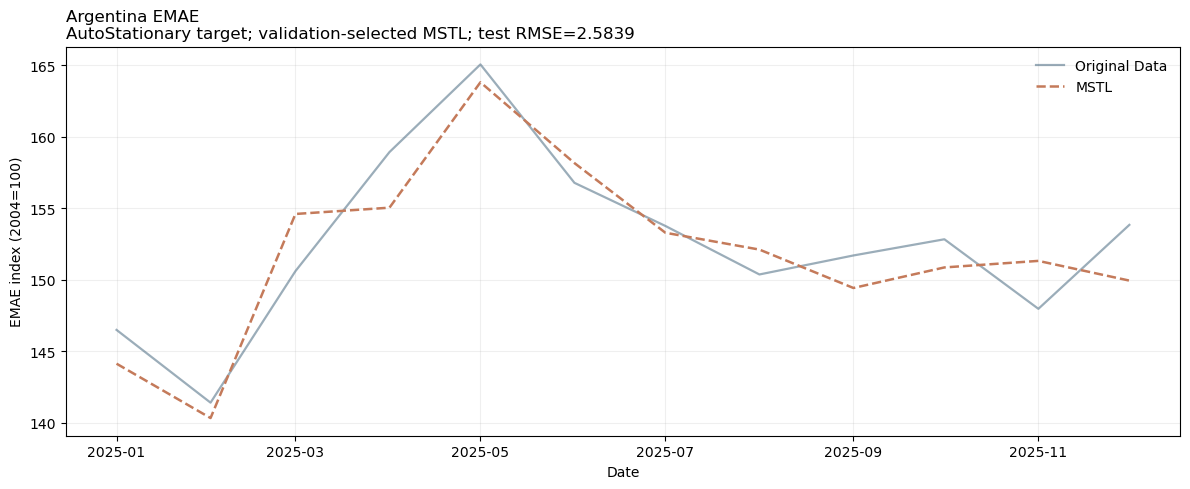

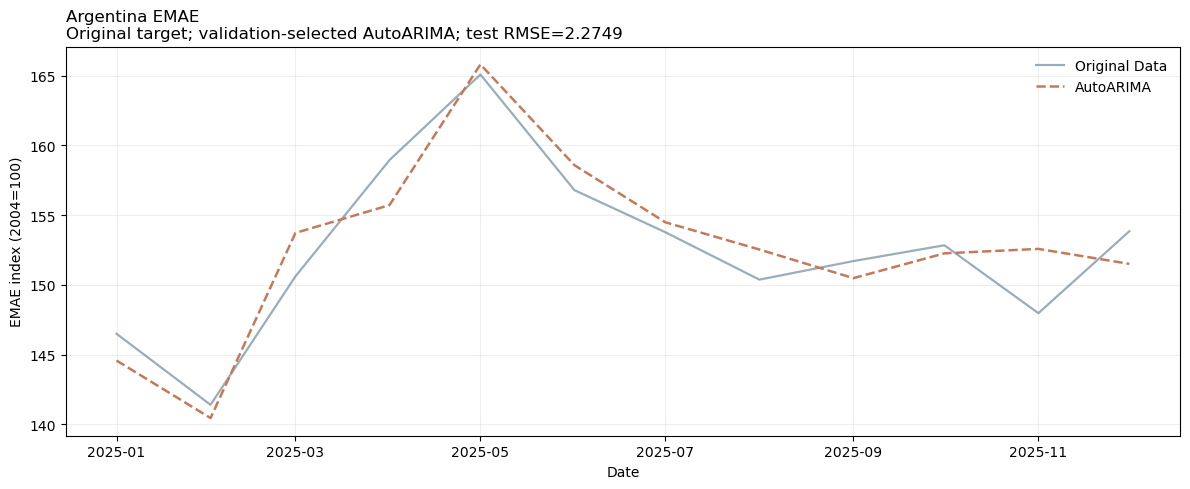


PLOTTING: ecai_us (manual)



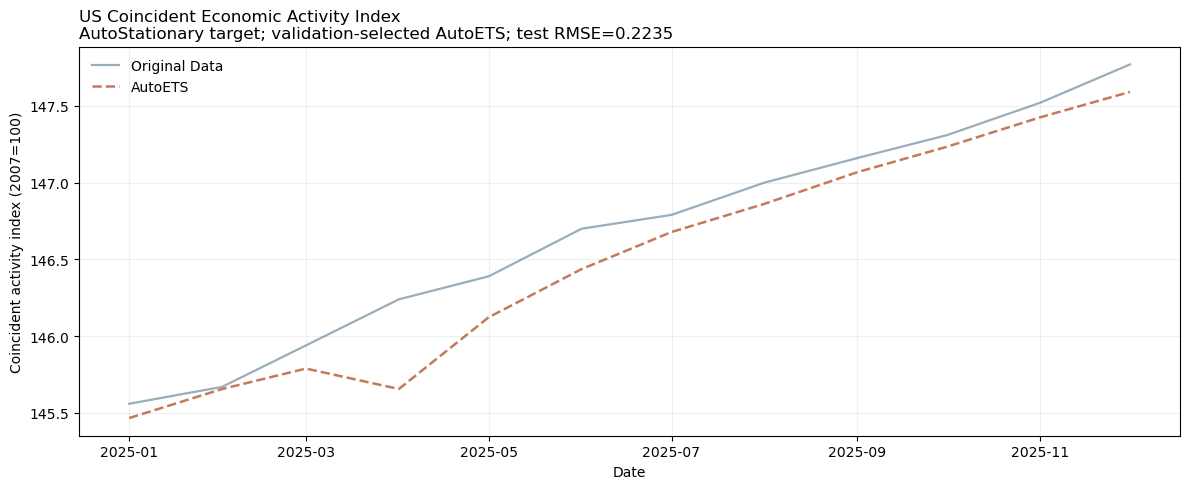

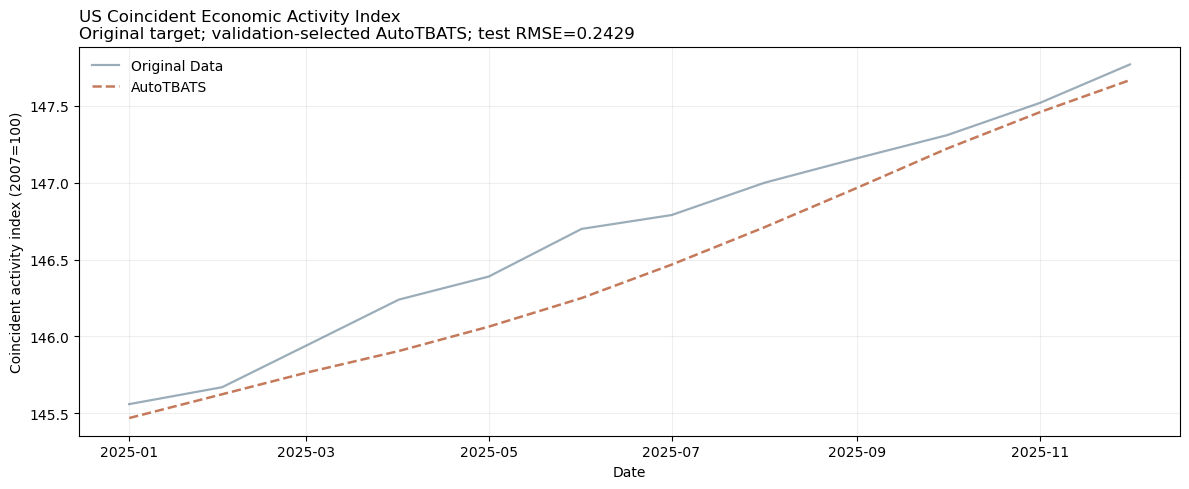


PLOTTING: real_gdp_argentina (manual)



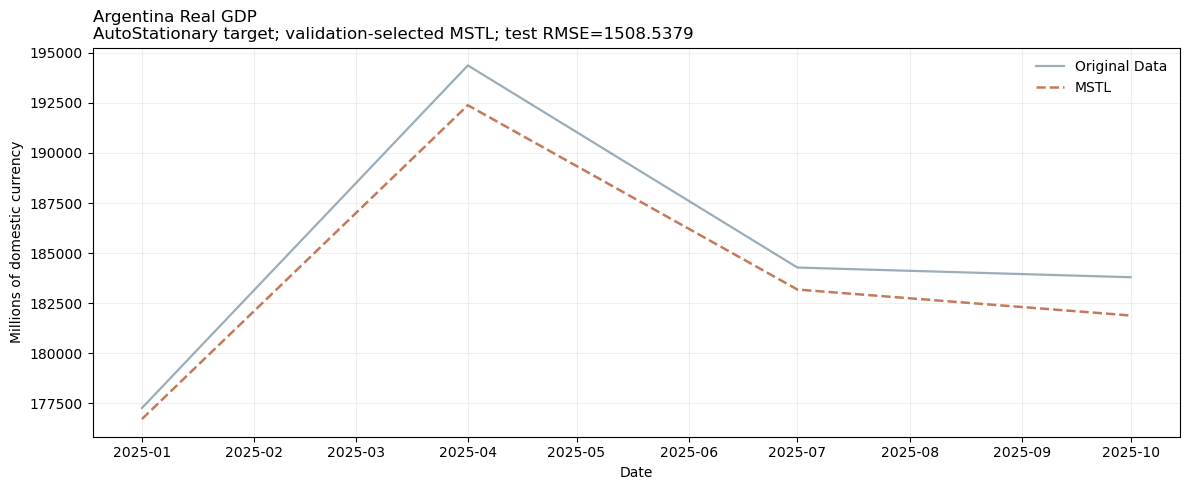

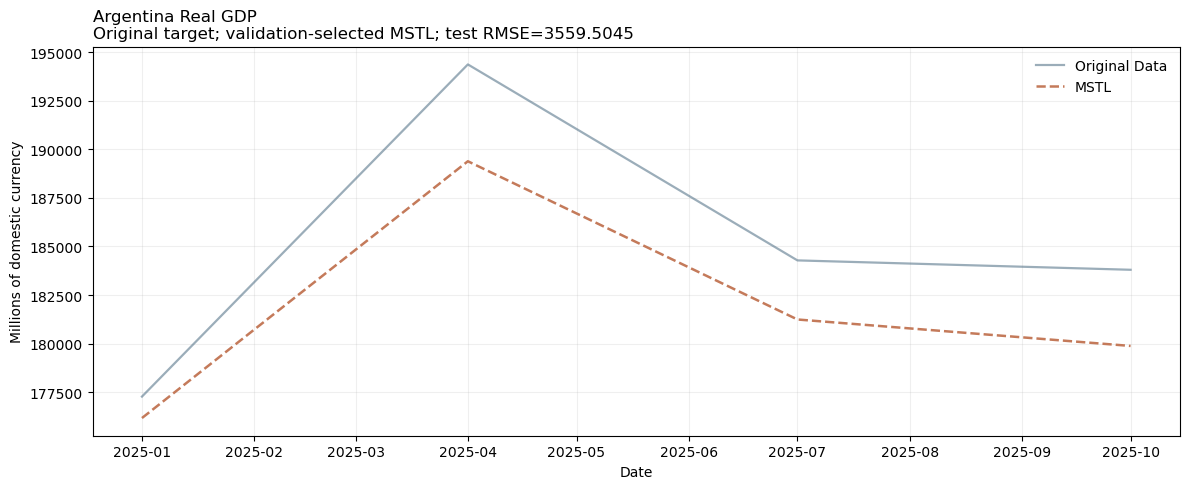


PLOTTING: real_gdp_us (manual)



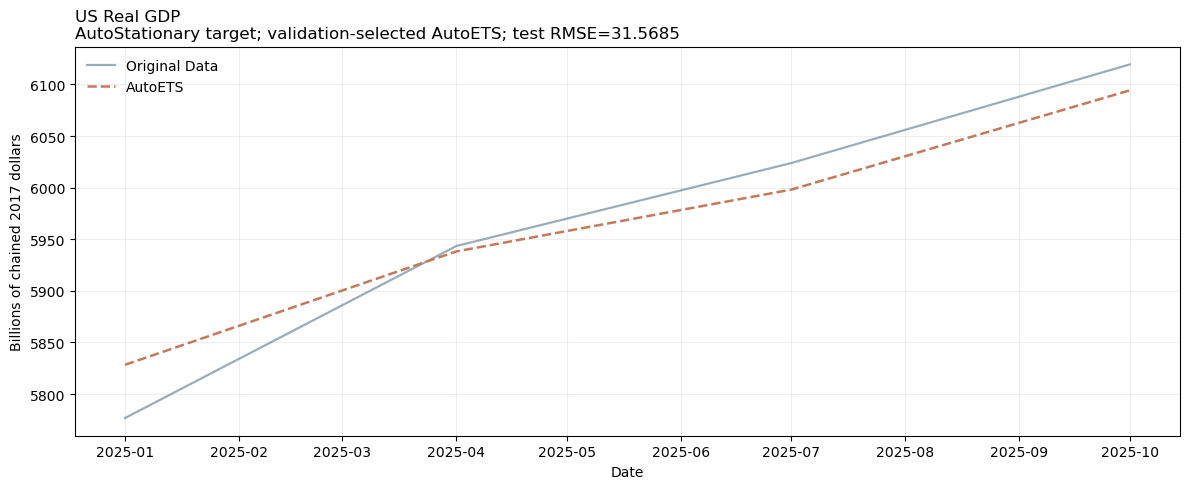

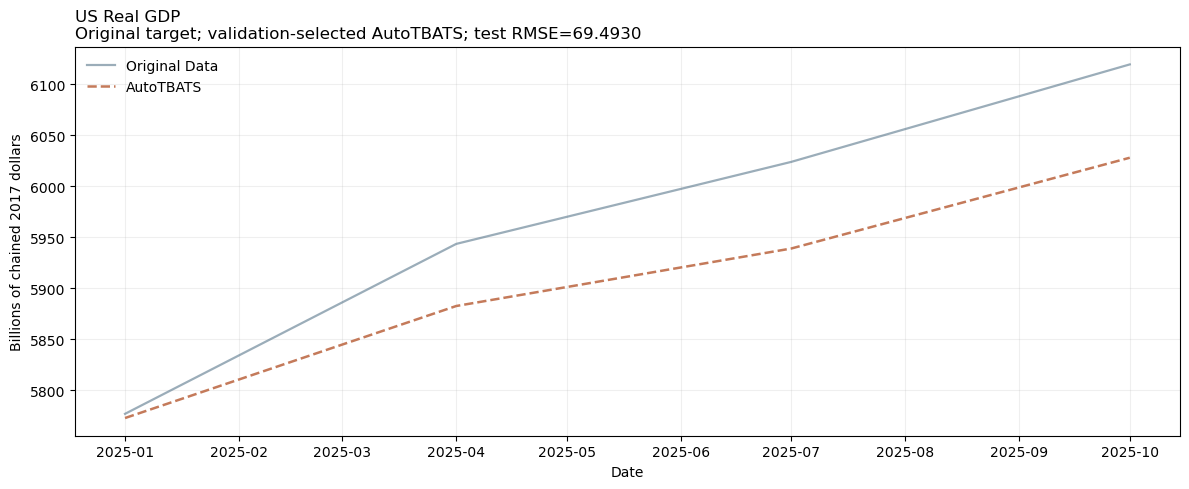


✓ Plotting complete



In [17]:
# ============================================================================
# PLOTTING: Show only each series/target version's validation-selected forecast
# ============================================================================

if EVALUATION_SPLIT == 'validation':
    plot_selection_metrics = {
        data['config'].get('selection_metric', 'rmse')
        for data in all_results.values()
    }
    if len(plot_selection_metrics) != 1:
        raise ValueError('Plot selection requires one common metric')
    plot_selection = summarize_model_selection(
        {name: data['metrics'] for name, data in all_results.items()},
        classical_configs_by_dataset,
        metric=plot_selection_metrics.pop(),
        series_col={name: data['id_col'] for name, data in all_results.items()},
        aggregate_replicates=False,
    )
else:
    plot_selection = frozen_selection

for dataset_name, data in all_results.items():
    dataset_config = data['config']
    dataset_type = data['type']
    metrics = data['metrics']
    results = data['results']
    id_col = data['id_col']
    time_col = data['time_col']
    target_col = data['target_col']
    
    print(f"\n{'='*80}")
    print(f"PLOTTING: {dataset_name} ({dataset_type})")
    print(f"{'='*80}\n")

    if plot_selection is not None:
        for series_name, target_winners in plot_selection['per_series'][dataset_name].items():
            plot_series_name = series_name
            plot_series_label = display_series_name(dataset_name, series_name)
            series_results = results[
                results[id_col].astype(str).eq(str(plot_series_name))
            ]
            for target_version, winner in target_winners.items():
                model_name = winner['model']
                metric_row = metrics[
                    metrics[id_col].astype(str).eq(str(plot_series_name))
                    & metrics['Target Transformation'].eq(target_version)
                    & metrics['Model'].eq(model_name)
                ].iloc[0]
                fig = plot_forecast_matplotlib(
                    series_results, [model_name], time_col, target_col,
                    forecast_display_names=[winner['base_model']],
                )
                apply_matplotlib_dataset_labels(
                    fig, dataset_name,
                    title_suffix=(
                        f'{target_version} target; '
                        f"validation-selected {winner['base_model']}; "
                        f"{EVALUATION_SPLIT} RMSE={metric_row['rmse']:.4f}"
                    ),
                )
                save_matplotlib_figure(
                    fig,
                    figure_path(
                        'classical_models', dataset_name, target_version,
                        EVALUATION_SPLIT, winner['base_model'],
                        extension=FIGURE_FORMAT,
                    ),
                    SAVE_FIGURES,
                )
                plt.show()
                plt.close(fig)
        continue

print(f"\n{'='*80}")
print(f"✓ Plotting complete")
print(f"{'='*80}\n")


In [18]:
# ============================================================================
# GENERATE RESULTS TABLES
# ============================================================================

all_tables = {}  # {dataset: {target version: result table}}

for dataset_name, data in all_results.items():
    dataset_config = data['config']
    dataset_type = data['type']
    id_col = data['id_col']
    
    print(f"\nProcessing results for: {dataset_name}")
    all_tables[dataset_name] = {
        'Original': humanize_results_table(
            build_results_table(data['metrics_original'], id_col, dataset_type),
            dataset_name,
        ),
        'AutoStationary': humanize_results_table(
            build_results_table(data['metrics_transformed'], id_col, dataset_type),
            dataset_name,
        ),
    }
    for target_version, result_table in all_tables[dataset_name].items():
        print(
            f"  ✓ {target_version}: {len(result_table)} rows "
            f"({data['metrics'][id_col].nunique()} series × "
            f"{result_table['Model'].nunique()} models)"
        )



Processing results for: emae
  ✓ Original: 1 rows (1 series × 1 models)
  ✓ AutoStationary: 1 rows (1 series × 1 models)

Processing results for: ecai_us
  ✓ Original: 1 rows (1 series × 1 models)
  ✓ AutoStationary: 1 rows (1 series × 1 models)

Processing results for: real_gdp_argentina
  ✓ Original: 1 rows (1 series × 1 models)
  ✓ AutoStationary: 1 rows (1 series × 1 models)

Processing results for: real_gdp_us
  ✓ Original: 1 rows (1 series × 1 models)
  ✓ AutoStationary: 1 rows (1 series × 1 models)


In [19]:
# ============================================================================
# DISPLAY RESULTS TABLES WITH HIGHLIGHTING
# ============================================================================

def color_best_per_series(df):
    """Apply green background to best values per metric per series.
    
    For most metrics: highlight minimum values (better = lower)
    For Forecast Bias: highlight value closest to zero (better = closer to 0, regardless of sign)
    For Time Elapsed: highlight minimum values (faster = better)
    """
    styled = df.style.format({
        'MAE': '{:.4f}',
        'MSE': '{:.4f}',
        'RMSE': '{:.4f}',
        'Forecast Bias': '{:.2f}',
        'Time Elapsed': '{:.6f}'
    }) if 'Time Elapsed' in df.columns else df.style.format({
        'MAE': '{:.4f}',
        'MSE': '{:.4f}',
        'RMSE': '{:.4f}',
        'Forecast Bias': '{:.2f}'
    })
    
    # Highlight minimum values per series for key metrics (except Forecast Bias)
    for metric in ['MAE', 'MSE', 'RMSE', 'Time Elapsed']:
        if metric not in df.columns:
            continue
        groups = df.groupby('Series Name') if 'Series Name' in df else [(None, df)]
        for _, series_data in groups:
            min_idx = series_data[metric].idxmin()
            styled = styled.highlight_max(subset=pd.IndexSlice[[min_idx], [metric]], color='lightgreen')
    
    # For Forecast Bias: highlight value closest to zero (minimum absolute value)
    if 'Forecast Bias' in df.columns:
        groups = df.groupby('Series Name') if 'Series Name' in df else [(None, df)]
        for _, series_data in groups:
            # Find the index where absolute bias is smallest
            closest_to_zero_idx = series_data['Forecast Bias'].abs().idxmin()
            styled = styled.highlight_max(subset=pd.IndexSlice[[closest_to_zero_idx], ['Forecast Bias']], color='lightgreen')
    
    return styled

# Display each dataset's table
for dataset_name, version_tables in all_tables.items():
    dataset_config = all_results[dataset_name]['config']
    dataset_type = all_results[dataset_name]['type']
    for target_version, result_table in version_tables.items():
        print(f"\n{'='*100}")
        print(
            f"TABLE: {dataset_config['label']} ({dataset_type}) — "
            f"{target_version} target"
        )
        print(f"{'='*100}")
        display(color_best_per_series(result_table))
        print(f"\nDataset: {dataset_config['label']}")
        print(
            f"Series: {all_results[dataset_name]['metrics'][all_results[dataset_name]['id_col']].nunique()} | "
            f"Models: {result_table['Model'].nunique()}"
        )



TABLE: EMAE (Argentina) (manual) — Original target


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,AutoARIMA,1.9451,5.1750,2.2749,0.16,4.112842



Dataset: EMAE (Argentina)
Series: 1 | Models: 1

TABLE: EMAE (Argentina) (manual) — AutoStationary target


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,MSTL_AutoStationary,2.3065,6.6763,2.5839,-0.37,0.018568



Dataset: EMAE (Argentina)
Series: 1 | Models: 1

TABLE: Coincident Economic Activity Index (United States) (manual) — Original target


...


Dataset: Real GDP (Argentina)
Series: 1 | Models: 1

TABLE: Real GDP (United States) (manual) — Original target


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,AutoTBATS,60.3705,4829.2817,69.4930,-1.01,5.801235



Dataset: Real GDP (United States)
Series: 1 | Models: 1

TABLE: Real GDP (United States) (manual) — AutoStationary target


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,AutoETS_AutoStationary,26.9357,996.5698,31.5685,-0.02,0.017437



Dataset: Real GDP (United States)
Series: 1 | Models: 1


In [20]:
# ============================================================================
# LaTeX EXPORT
# ============================================================================

print(f"\n{'='*100}")
print(f"LaTeX EXPORT")
print(f"{'='*100}")

# Create output directory if it doesn't exist
os.makedirs('thesis/results', exist_ok=True)

for dataset_name, version_tables in all_tables.items():
    print(f"\n{'-'*100}")
    print(f"Dataset: {dataset_name}")
    print(f"{'-'*100}")
    
    latex_sections = []
    for target_version, result_table in version_tables.items():
        reporting = all_results[dataset_name]['config']['reporting']
        latex_table = publication_latex(
            result_table,
            caption=(
                f"{reporting['display_name']}; {reporting['frequency']}; "
                f"{reporting['units']}; {reporting['seasonal_adjustment']}. "
                f"Classical {EVALUATION_SPLIT} results on the {target_version} target."
            ),
            label=f'tab:classical-{EVALUATION_SPLIT}-{dataset_name}-{target_version.lower()}',
            float_format=lambda x: (
                f'{x:.6f}' if abs(x) < 100 else f'{x:.2f}'
            ),
        )
        latex_sections.append(
            f"% {target_version} target\n{latex_table}"
        )
        print(f"\nLaTeX TABLE CODE — {target_version}:")
        print(latex_table)
    combined_latex = '\n\n'.join(latex_sections)
    
    # Save to file
    output_file = f'thesis/results/results_table_classical_{EVALUATION_SPLIT}_{dataset_name}.tex'
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(combined_latex)
    
    print(f"\n✓ Saved to: {output_file}")

print(f"\n{'='*100}")
print(f"✓ All tables exported")
print(f"{'='*100}")



LaTeX EXPORT

----------------------------------------------------------------------------------------------------
Dataset: emae
----------------------------------------------------------------------------------------------------

LaTeX TABLE CODE — Original:
\begin{table}[htbp]
\caption{Argentina EMAE; Monthly; Index (2004=100); Original series (not seasonally adjusted). Classical test results on the Original target.}
\label{tab:classical-test-emae-original}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{lrrrrr}
\toprule
Model & MAE & MSE & RMSE & Forecast Bias & Time Elapsed \\
\midrule
AutoARIMA & \textcolor{metricgreen}{1.945080} & \textcolor{metricgreen}{5.174976} & \textcolor{metricgreen}{\textbf{2.274857}} & \textcolor{metricgreen}{0.156697} & \textcolor{metricgreen}{\textbf{4.112842}} \\
\bottomrule
\end{tabular}
\end{adjustbox}
\end{table}


LaTeX TABLE CODE — AutoStationary:
\begin{table}[htbp]
\caption{Argentina EMAE; Monthly; Index (2004=100); Original series (not

In [21]:
# ============================================================================
# VALIDATION MODEL SELECTION AND CONFIGURATION STORAGE
# ============================================================================

print(f"\n{'='*100}")
print("BEST MODEL ANALYSIS")
print(f"{'='*100}\n")

if EVALUATION_SPLIT == 'validation':
    selection_metrics = {
        data['config'].get('selection_metric', 'rmse')
        for data in all_results.values()
    }
    if len(selection_metrics) != 1:
        raise ValueError('Overall ranking requires one common selection metric')
    selection_metric = selection_metrics.pop()
    new_classical_selection = summarize_model_selection(
        {name: data['metrics'] for name, data in all_results.items()},
        classical_configs_by_dataset,
        metric=selection_metric,
        aggregate_replicates=False,
    )
    classical_selection = (
        merge_model_selections(
            load_model_selection(CLASSICAL_SELECTION_PATH), new_classical_selection
        )
        if CLASSICAL_SELECTION_PATH.exists() else new_classical_selection
    )
    selection_path = export_model_selection(
        classical_selection,
        CLASSICAL_SELECTION_PATH,
    )
    for dataset_name, target_winners in classical_selection['per_dataset'].items():
        for target_version, winner in target_winners.items():
            print(
                f"{dataset_name} [{target_version}]: {winner['model']} | "
                f"{selection_metric.upper()}={winner['validation_score']:.6f}"
            )
    for target_version, overall in classical_selection['overall_by_target'].items():
        print(
            f"\nCross-dataset candidate for a later global benchmark ({target_version}): "
            f"{overall['model']} | "
            f"mean rank={overall['mean_rank']:.3f}"
        )
    print(f"✓ Selection saved to: {selection_path}")
    print("This is the validation selection report. Set EVALUATION_SPLIT='test' and rerun from the top for the locked final-test report.")
else:
    selection_file = CLASSICAL_SELECTION_PATH
    if not selection_file.exists():
        raise FileNotFoundError(
            f'No frozen validation selection found at {selection_file}; run validation first.'
        )
    frozen_selection = load_model_selection(selection_file)
    print('FINAL TEST REPORT - validation-selected winners only')
    for dataset_name, data in all_results.items():
        selected_rows = []
        series_winners = frozen_selection['per_series'].get(dataset_name, {})
        for series_name, target_winners in series_winners.items():
            metric_series = data['metrics'][data['id_col']].astype(str)
            for target_version, winner in target_winners.items():
                mask = (
                    metric_series.eq(str(series_name))
                    & data['metrics']['Target Transformation'].eq(target_version)
                    & data['metrics']['Model'].eq(winner['model'])
                )
                winner_test = data['metrics'].loc[mask].copy()
                if winner_test.empty:
                    raise ValueError(
                        f"Missing test result for {dataset_name} / {series_name} / "
                        f"{target_version} / {winner['model']}"
                    )
                winner_test['Validation Score'] = winner['validation_score']
                winner_test['Selection Metric'] = winner['selection_metric'].upper()
                selected_rows.append(winner_test)
        if not selected_rows:
            raise ValueError(f'No per-series validation winners found for {dataset_name}')
        locked_test_metrics = pd.concat(selected_rows, ignore_index=True)
        report_columns = [
            data['id_col'], 'Target Transformation', 'Model',
            'Selection Metric', 'Validation Score',
            'mae', 'mse', 'rmse', 'forecast_bias', 'Time Elapsed',
        ]
        print(f'\n{dataset_name}: locked validation winners evaluated on test')
        display(
            locked_test_metrics[
                [column for column in report_columns if column in locked_test_metrics]
            ].sort_values([data['id_col'], 'Target Transformation'])
        )
    print('Validation selections were loaded read-only and were not overwritten.')



BEST MODEL ANALYSIS

FINAL TEST REPORT - validation-selected winners only

emae: locked validation winners evaluated on test


,unique_id,Target Transformation,Model,Selection Metric,Validation Score,mae,mse,rmse,forecast_bias,Time Elapsed
0,EMAE,AutoStationary,MSTL_AutoStationary,RMSE,3.778436,2.30646,6.676322,2.583858,-0.367495,0.018568
1,EMAE,Original,AutoARIMA,RMSE,4.450574,1.94508,5.174976,2.274857,0.156697,4.112842



ecai_us: locked validation winners evaluated on test


,unique_id,Target Transformation,Model,Selection Metric,Validation Score,mae,mse,rmse,forecast_bias,Time Elapsed
0,ECAI_US,AutoStationary,AutoETS_AutoStationary,RMSE,0.598432,0.171901,0.049951,0.223497,-0.117202,0.098765
1,ECAI_US,Original,AutoTBATS,RMSE,0.720073,0.206341,0.059014,0.242928,-0.140683,2.516987



real_gdp_argentina: locked validation winners evaluated on test


,unique_id,Target Transformation,Model,Selection Metric,Validation Score,mae,mse,rmse,forecast_bias,Time Elapsed
0,REAL_GDP_ARGENTINA,AutoStationary,MSTL_AutoStationary,RMSE,4005.291988,1386.092628,2.275687e+06,1508.537946,-0.749514,0.008011
1,REAL_GDP_ARGENTINA,Original,MSTL,RMSE,4133.432621,3262.490007,1.267007e+07,3559.504473,-1.764155,0.007179



real_gdp_us: locked validation winners evaluated on test


,unique_id,Target Transformation,Model,Selection Metric,Validation Score,mae,mse,rmse,forecast_bias,Time Elapsed
0,REAL_GDP_US,AutoStationary,AutoETS_AutoStationary,RMSE,43.714855,26.935697,996.569834,31.568494,-0.018944,0.017437
1,REAL_GDP_US,Original,AutoTBATS,RMSE,22.201184,60.370460,4829.281718,69.493034,-1.011939,5.801235


Validation selections were loaded read-only and were not overwritten.


In [22]:

# ============================================================================
# EXPORT METRICS TO FILE FOR COMPARISON
# ============================================================================

os.makedirs('thesis/metrics', exist_ok=True)
os.makedirs('thesis/predictions', exist_ok=True)

print(f"\n{'='*100}")
print(f"EXPORTING METRICS FOR COMPARISON")
print(f"{'='*100}\n")

classical_comparison_tables = []

for dataset_name, data in all_results.items():
    reporting_metrics = data['metrics']
    comparison_table = prepare_comparison_metrics(
        reporting_metrics,
        dataset_name=dataset_name,
        dataset_type=data['type'],
        series_col=data['id_col'],
        model_family='Classical',
        target_transformation='Original',
        split=EVALUATION_SPLIT,
    )
    paths = export_comparison_metrics(
        comparison_table,
        f'classical_models_{EVALUATION_SPLIT}',
        dataset_name,
    )
    classical_comparison_tables.append(comparison_table)
    print(f"✓ Metrics CSV: {paths['csv']}")
    prediction_path = Path(
        f'thesis/predictions/classical_{EVALUATION_SPLIT}_predictions_{dataset_name}.csv'
    )
    data['results'].to_csv(prediction_path, index=False)
    print(f"✓ Forecast CSV: {prediction_path}")

if classical_comparison_tables and EXECUTION_MODE == 'batch':
    classical_metrics_all = pd.concat(classical_comparison_tables, ignore_index=True)
    export_comparison_metrics(
        classical_metrics_all, f'classical_models_{EVALUATION_SPLIT}', 'all'
    )
elif EXECUTION_MODE == 'single':
    print('Single mode leaves the complete batch metrics_all file unchanged.')

# End-of-run EMAE and batch-output verification.
emae_frame, emae_config = load_dataset('emae', 'manual')
_, emae_validation, emae_test, emae_id, emae_time, emae_target = (
    create_train_val_test_splits(emae_frame, emae_config, 'manual')
)
assert emae_validation.groupby(emae_id).size().eq(12).all()
assert emae_test.groupby(emae_id).size().eq(12).all()
assert pd.DatetimeIndex(
    pd.to_datetime(emae_test[emae_time]).drop_duplicates().sort_values()
).equals(pd.date_range('2025-01-01', '2025-12-01', freq='MS'))
if 'emae' in all_results:
    emae_run = all_results['emae']
    emae_predictions = emae_run['results'].copy()
    emae_predictions[emae_time] = pd.to_datetime(emae_predictions[emae_time])
    expected_dates = pd.date_range(
        '2024-01-01' if EVALUATION_SPLIT == 'validation' else '2025-01-01',
        periods=12, freq='MS',
    )
    assert pd.DatetimeIndex(
        emae_predictions[emae_time].drop_duplicates().sort_values()
    ).equals(expected_dates)
    compared_models = emae_run['metrics']['Model'].drop_duplicates().tolist()
    assert set(compared_models).issubset(emae_predictions.columns)
    for model_name in compared_models:
        model_dates = pd.DatetimeIndex(
            emae_predictions.loc[
                emae_predictions[model_name].notna(), emae_time
            ].drop_duplicates().sort_values()
        )
        assert model_dates.equals(expected_dates), model_name
    if EVALUATION_SPLIT == 'test':
        fit_dates = pd.to_datetime(emae_run['fit_df'][emae_time])
        assert fit_dates.max() < expected_dates.min()
        december = emae_predictions.loc[
            emae_predictions[emae_time].eq(pd.Timestamp('2025-12-01'))
        ]
        assert len(december) == 1
        assert december[compared_models].notna().all().all()
if EXECUTION_MODE == 'batch':
    expected_batch = set(POINT_FORECAST_DATASETS)
    assert set(all_results) == expected_batch
    assert set(all_tables) == expected_batch
    assert set(classical_metrics_all['Dataset']) == expected_batch
    saved_all = pd.read_csv(
        f'thesis/metrics/classical_models_{EVALUATION_SPLIT}_metrics_all.csv'
    )
    assert set(saved_all['Dataset']) == expected_batch
    for dataset_name in expected_batch:
        table_path = Path(
            f'thesis/results/results_table_classical_{EVALUATION_SPLIT}_{dataset_name}.tex'
        )
        assert table_path.is_file() and table_path.stat().st_size > 0
print('EMAE horizon and batch-consolidation checks passed.')

print(f"\n✓ Classical models metrics exported - ready for comparison with ML models")



EXPORTING METRICS FOR COMPARISON

✓ Metrics CSV: thesis/metrics\classical_models_test_metrics_emae.csv
✓ Forecast CSV: thesis\predictions\classical_test_predictions_emae.csv
✓ Metrics CSV: thesis/metrics\classical_models_test_metrics_ecai_us.csv
✓ Forecast CSV: thesis\predictions\classical_test_predictions_ecai_us.csv
✓ Metrics CSV: thesis/metrics\classical_models_test_metrics_real_gdp_argentina.csv
✓ Forecast CSV: thesis\predictions\classical_test_predictions_real_gdp_argentina.csv
✓ Metrics CSV: thesis/metrics\classical_models_test_metrics_real_gdp_us.csv
✓ Forecast CSV: thesis\predictions\classical_test_predictions_real_gdp_us.csv
EMAE horizon and batch-consolidation checks passed.

✓ Classical models metrics exported - ready for comparison with ML models
